In [1]:
# Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df=pd.read_csv(r"C:\Users\12622\Desktop\guvi_projects\Mobile_Product_Segmentation_Recommendation\data\Mobile Reviews Sentiment null.csv")

In [11]:
df.head()

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy


In [12]:
df.shape

(50000, 22)

In [13]:
df.columns

Index(['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd',
       'price_local', 'currency', 'exchange_rate_to_usd', 'rating',
       'sentiment', 'country', 'language', 'review_date', 'verified_purchase',
       'battery_life_rating', 'camera_rating', 'performance_rating',
       'design_rating', 'display_rating', 'helpful_votes', 'source'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             47550 non-null  float64
 6   price_local           47569 non-null  object 
 7   currency              50000 non-null  object 
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                47547 non-null  float64
 10  sentiment             47555 non-null  object 
 11  country               50000 non-null  object 
 12  language              50000 non-null  object 
 13  review_date           50000 non-null  object 
 14  verified_purchase     50000 non-null  bool   
 15  battery_life_rating

In [16]:
df.describe()

,review_id,age,price_usd,exchange_rate_to_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
count,50000.000000,50000.000000,47550.00000,50000.000000,47547.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,30.075220,689.89277,12.057946,3.123415,2.71800,2.717640,2.719620,2.713960,2.721280,3.644180
std,14433.901067,8.931307,310.32722,26.553332,1.249067,1.34827,1.345001,1.349208,1.343346,1.352121,2.432745
min,1.000000,18.000000,180.02000,0.780000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,12500.750000,23.000000,450.75500,1.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,25000.500000,29.000000,637.58500,1.530000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,37500.250000,36.000000,901.45750,5.700000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000
max,50000.000000,65.000000,1499.89000,83.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,17.000000


In [17]:
#missing value analysis

In [19]:
df.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                  2453
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                  2448
dtype: int64

In [21]:
# calculating missing percentage

In [22]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({"Missing Count": df.isnull().sum(),"Missing Percentage": missing_percentage})
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing Percentage", ascending=False)
missing_summary

,Missing Count,Missing Percentage
rating,2453,4.906
price_usd,2450,4.900
source,2448,4.896
sentiment,2445,4.890
price_local,2431,4.862


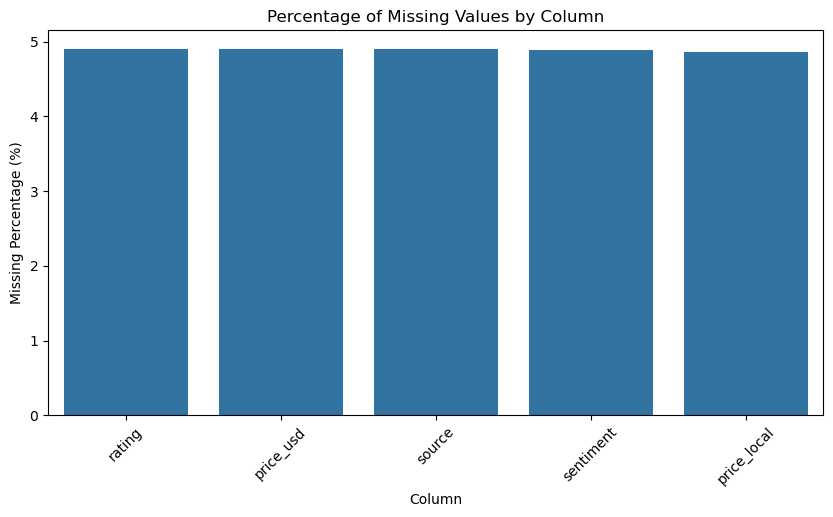

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_summary.index,y=missing_summary["Missing Percentage"])
plt.title("Percentage of Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)
plt.show()

In [24]:
#check for duplicates

In [25]:
duplicate_count = df.duplicated().sum()

In [26]:
duplicate_count

np.int64(0)

In [27]:
duplicate_ids = df["review_id"].duplicated().sum()
duplicate_ids

np.int64(0)

In [28]:
# cleaning price local column

In [29]:
df["price_local_numeric"] = (df["price_local"].astype(str).str.replace(r"[^0-9.\-]", "", regex=True))
df["price_local_numeric"] = pd.to_numeric(df["price_local_numeric"],errors="coerce")

In [30]:
df[["price_local", "price_local_numeric"]].head(10)

,price_local,price_local_numeric
0,₹27996.73,27996.73
1,R$1754.35,1754.35
2,₹71755.99,71755.99
3,د.إ2425.65,NaN
4,R$4515.14,4515.14
5,R$5408.1,5408.10
6,د.إ1541.88,NaN
7,A$2208.95,2208.95
8,€256.43,256.43
9,A$834.72,834.72


In [31]:
#replaceprevious version

In [32]:
df["price_local_numeric"] = (df["price_local"].astype(str).str.extract(r"(\d+(?:\.\d+)?)$")[0])

df["price_local_numeric"] = pd.to_numeric(df["price_local_numeric"],errors="coerce")

In [33]:
df[["price_local", "price_local_numeric"]].head(10)

,price_local,price_local_numeric
0,₹27996.73,27996.73
1,R$1754.35,1754.35
2,₹71755.99,71755.99
3,د.إ2425.65,2425.65
4,R$4515.14,4515.14
5,R$5408.1,5408.10
6,د.إ1541.88,1541.88
7,A$2208.95,2208.95
8,€256.43,256.43
9,A$834.72,834.72


In [34]:
df["price_local_numeric"].isnull().sum()

np.int64(8563)

In [35]:
#find whichcurrency causing problem 

In [36]:
df.loc[df["price_local_numeric"].isna(),["price_local", "currency", "price_usd", "exchange_rate_to_usd"]].head(20)

,price_local,currency,price_usd,exchange_rate_to_usd
16,"$1,010.68",USD,1010.68,1.00
24,$997.61,USD,997.61,1.00
29,NaN,INR,1369.88,83.00
42,$924.51,USD,924.51,1.00
44,$267.21,USD,NaN,1.00
48,$969.89,USD,969.89,1.00
49,NaN,CAD,574.70,1.38
56,NaN,GBP,633.36,0.78
60,NaN,USD,458.08,1.00
65,$857.76,USD,857.76,1.00


In [37]:
df.loc[df["price_local_numeric"].isna(),"currency"].value_counts()

currency
USD    6435
BRL     325
AUD     318
AED     315
GBP     311
INR     303
EUR     294
CAD     262
Name: count, dtype: int64

In [38]:
df.loc[df["price_local_numeric"].isna(),["price_local", "currency", "price_usd", "exchange_rate_to_usd"]].head(20)

,price_local,currency,price_usd,exchange_rate_to_usd
16,"$1,010.68",USD,1010.68,1.00
24,$997.61,USD,997.61,1.00
29,NaN,INR,1369.88,83.00
42,$924.51,USD,924.51,1.00
44,$267.21,USD,NaN,1.00
48,$969.89,USD,969.89,1.00
49,NaN,CAD,574.70,1.38
56,NaN,GBP,633.36,0.78
60,NaN,USD,458.08,1.00
65,$857.76,USD,857.76,1.00


In [39]:
df.loc[df["price_local_numeric"].isna(),"price_local"].head(20).tolist()

['$1,010.68 ',
 '$997.61 ',
 nan,
 '$924.51 ',
 '$267.21 ',
 '$969.89 ',
 nan,
 nan,
 nan,
 '$857.76 ',
 nan,
 nan,
 nan,
 '$856.62 ',
 nan,
 '$530.14 ',
 '$615.46 ',
 '$463.17 ',
 '$417.44 ',
 '$193.94 ']

In [40]:
#corect local price conversion

In [41]:
# Remove currency symbols, commas and extra spaces

In [42]:
df["price_local_numeric"] = (df["price_local"].astype("string").str.replace(",", "", regex=False).str.extract(r"(\d+(?:\.\d+)?)")[0])
df["price_local_numeric"] = pd.to_numeric(df["price_local_numeric"],errors="coerce")

In [43]:
df[["price_local", "price_local_numeric"]].head(20)

,price_local,price_local_numeric
0,₹27996.73,27996.73
1,R$1754.35,1754.35
2,₹71755.99,71755.99
3,د.إ2425.65,2425.65
4,R$4515.14,4515.14
5,R$5408.1,5408.1
6,د.إ1541.88,1541.88
7,A$2208.95,2208.95
8,€256.43,256.43
9,A$834.72,834.72


In [44]:
df["price_local_numeric"].isna().sum()

np.int64(2431)

In [45]:
#fill missing local prices using exchange rate

In [46]:
missing_local = df["price_local_numeric"].isna()
df.loc[missing_local, "price_local_numeric"] = (df.loc[missing_local, "price_usd"]* df.loc[missing_local, "exchange_rate_to_usd"]).round(2)

In [47]:
 df["price_local_numeric"].isna().sum()

np.int64(123)

In [48]:
df.loc[df["price_local_numeric"].isna(),["price_local", "price_usd", "currency", "exchange_rate_to_usd"]].head(20)


,price_local,price_usd,currency,exchange_rate_to_usd
1428,NaN,NaN,GBP,0.78
2048,NaN,NaN,AUD,1.53
2193,NaN,NaN,USD,1.00
2310,NaN,NaN,BRL,5.70
2774,NaN,NaN,INR,83.00
2962,NaN,NaN,AUD,1.53
3377,NaN,NaN,AUD,1.53
3696,NaN,NaN,AED,3.67
3870,NaN,NaN,AED,3.67
4482,NaN,NaN,AUD,1.53


In [49]:
df.loc[df["price_local_numeric"].isna(),["price_usd", "currency", "exchange_rate_to_usd"]].isna().sum()

price_usd               123
currency                  0
exchange_rate_to_usd      0
dtype: int64

In [50]:
#check whether the same model has prices elsewhere

In [51]:
missing_price_rows = df["price_local_numeric"].isna()
df.loc[missing_price_rows,["model", "brand", "currency", "exchange_rate_to_usd"]].head(20)

,model,brand,currency,exchange_rate_to_usd
1428,Poco X6,Xiaomi,GBP,0.78
2048,OnePlus 11R,OnePlus,AUD,1.53
2193,OnePlus 11R,OnePlus,USD,1.00
2310,Poco X6,Xiaomi,BRL,5.70
2774,OnePlus 12,OnePlus,INR,83.00
2962,Galaxy A55,Samsung,AUD,1.53
3377,Redmi Note 13,Xiaomi,AUD,1.53
3696,Razr 40,Motorola,AED,3.67
3870,Galaxy S24,Samsung,AED,3.67
4482,iPhone 15 Pro,Apple,AUD,1.53


In [52]:
df.loc[missing_price_rows,"model"].value_counts().head(20)

model
Redmi Note 13      9
iPhone 14          9
Realme Narzo 70    9
Poco X6            7
Razr 40            7
Realme 12 Pro      7
Moto G Power       6
Pixel 8            6
Galaxy Z Flip      6
Edge 50            5
OnePlus 12         5
Galaxy S24         5
Mi 13 Pro          5
Pixel 7a           5
OnePlus Nord 3     4
iPhone SE          4
Galaxy Note 20     4
OnePlus 11R        4
iPhone 13          4
iPhone 15 Pro      4
Name: count, dtype: int64

In [53]:
df["price_usd"].isna().sum()

np.int64(2450)

In [57]:
df["price_usd"].isna()& df["price_local_numeric"].notna().sum()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Name: price_usd, Length: 50000, dtype: bool

In [58]:
missing_usd_with_local = (
    df["price_usd"].isna()
    & df["price_local_numeric"].notna()
).sum()

print(
    "Missing price_usd but available local price:",
    missing_usd_with_local
)

Missing price_usd but available local price: 2327


In [59]:
missing_local_with_usd = (
    df["price_local_numeric"].isna()
    & df["price_usd"].notna()
).sum()

print(
    "Missing local price but available USD price:",
    missing_local_with_usd
)

Missing local price but available USD price: 0


In [60]:
#recover the missing USD prices

In [62]:
missing_usd = df["price_usd"].isna()
df.loc[missing_usd, "price_usd"] = (df.loc[missing_usd, "price_local_numeric"]/ df.loc[missing_usd, "exchange_rate_to_usd"]).round(2)

In [63]:
df["price_usd"].isna().sum()

np.int64(123)

In [64]:
#handle the remaining 123 prices

In [65]:
missing_both_prices = (df["price_usd"].isna()& df["price_local_numeric"].isna())

In [66]:
missing_both_prices.sum()

np.int64(123)

In [67]:
df.loc[missing_both_prices,["brand", "model", "currency"]].head(20)

,brand,model,currency
1428,Xiaomi,Poco X6,GBP
2048,OnePlus,OnePlus 11R,AUD
2193,OnePlus,OnePlus 11R,USD
2310,Xiaomi,Poco X6,BRL
2774,OnePlus,OnePlus 12,INR
2962,Samsung,Galaxy A55,AUD
3377,Xiaomi,Redmi Note 13,AUD
3696,Motorola,Razr 40,AED
3870,Samsung,Galaxy S24,AED
4482,Apple,iPhone 15 Pro,AUD


In [68]:
df.loc[missing_both_prices,"model"].value_counts().head(20)

model
Redmi Note 13      9
iPhone 14          9
Realme Narzo 70    9
Poco X6            7
Razr 40            7
Realme 12 Pro      7
Moto G Power       6
Pixel 8            6
Galaxy Z Flip      6
Edge 50            5
OnePlus 12         5
Galaxy S24         5
Mi 13 Pro          5
Pixel 7a           5
OnePlus Nord 3     4
iPhone SE          4
Galaxy Note 20     4
OnePlus 11R        4
iPhone 13          4
iPhone 15 Pro      4
Name: count, dtype: int64

In [69]:
#fill the remaining 123 USD prices

In [70]:
model_median_price = df.groupby("model")["price_usd"].transform("median")
df["price_usd"] = df["price_usd"].fillna(model_median_price)

In [71]:
df["price_usd"].isna().sum()

np.int64(0)

In [73]:
#recover those 123 local prices

In [74]:
missing_local = df["price_local_numeric"].isna()
df.loc[missing_local, "price_local_numeric"] = (df.loc[missing_local, "price_usd"]* df.loc[missing_local, "exchange_rate_to_usd"]).round(2)

In [75]:
df["price_local_numeric"].isna().sum()

np.int64(0)

In [76]:
df["rating"].isna().sum()

np.int64(2453)

In [77]:
model_median_rating = df.groupby("model")["rating"].transform("median")
df["rating"] = df["rating"].fillna(model_median_rating)

In [79]:
df["rating"].isna().sum()

np.int64(0)

In [80]:
#clean sentiment

In [81]:
df["sentiment"].value_counts(dropna=False)

sentiment
Positive    26282
Neutral     11931
Negative     9342
NaN          2445
Name: count, dtype: int64

In [82]:
#Fill missing sentiment using rating

In [83]:
def sentiment_from_rating(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"
missing_sentiment = df["sentiment"].isna()
df.loc[missing_sentiment, "sentiment"] = (df.loc[missing_sentiment, "rating"].apply(sentiment_from_rating))

In [84]:
 df["sentiment"].isna().sum()

np.int64(0)

In [85]:
df["sentiment"].value_counts()

sentiment
Positive    27204
Neutral     12639
Negative    10157
Name: count, dtype: int64

In [86]:
#Clean categorical/text columns

In [87]:
categorical_columns = ["brand","model","country","language","source","currency"]
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))


--- brand ---
brand
Xiaomi      7241
Google      7234
Apple       7144
OnePlus     7136
Realme      7132
Motorola    7061
Samsung     7052
Name: count, dtype: int64

--- model ---
model
Realme Narzo 70    3597
Realme 12 Pro      3535
Redmi Note 13      2470
Pixel 7a           2468
Mi 13 Pro          2445
OnePlus 11R        2433
Razr 40            2395
Pixel 8            2387
OnePlus Nord 3     2380
Pixel 6            2379
Moto G Power       2351
Poco X6            2326
OnePlus 12         2323
Edge 50            2315
iPhone SE          1796
Name: count, dtype: int64

--- country ---
country
USA          6435
Brazil       6419
UAE          6261
Australia    6219
UK           6210
Canada       6170
Germany      6162
India        6124
Name: count, dtype: int64

--- language ---
language
English       31295
Portuguese     6419
German         6162
Hindi          6124
Name: count, dtype: int64

--- source ---
source
eBay          9573
AliExpress    9531
Amazon        9513
Flipkart      9481


In [88]:
#clean source

In [89]:
df["source"] = df["source"].fillna("Unknown")

In [90]:
df["source"].isna().sum()

np.int64(0)

In [91]:
df["source"].value_counts()

source
eBay          9573
AliExpress    9531
Amazon        9513
Flipkart      9481
BestBuy       9454
Unknown       2448
Name: count, dtype: int64

In [92]:
#check for unwanted space

In [93]:
text_columns = ["customer_name","brand","model", "country","language","sentiment","source","currency"]
for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

In [94]:
df[text_columns].isna().sum()

customer_name    0
brand            0
model            0
country          0
language         0
sentiment        0
source           0
currency         0
dtype: int64

In [95]:
df["review_date"].head(10)


0    11/6/2023
1    3/30/2023
2    12/7/2022
3    3/11/2025
4    9/29/2023
5    6/27/2023
6    3/27/2024
7     4/8/2024
8    10/4/2024
9    2/25/2025
Name: review_date, dtype: object

In [96]:
df["review_date"].dtype

dtype('O')

In [97]:
df["review_date"] = pd.to_datetime(df["review_date"],errors="coerce")

In [98]:
df["review_date"].isna().sum()

np.int64(0)

In [99]:
df["review_date"].dtype

dtype('<M8[ns]')

In [100]:
#create date features

In [101]:
df["review_year"] = df["review_date"].dt.year
df["review_month"] = df["review_date"].dt.month
df["review_month_name"] = df["review_date"].dt.month_name()
df["review_day_of_week"] = df["review_date"].dt.day_name()

In [102]:
#check new columns

In [103]:
print(df[["review_date","review_year","review_month","review_month_name","review_day_of_week"]].head(10))

  review_date  review_year  review_month review_month_name review_day_of_week
0  2023-11-06         2023            11          November             Monday
1  2023-03-30         2023             3             March           Thursday
2  2022-12-07         2022            12          December          Wednesday
3  2025-03-11         2025             3             March            Tuesday
4  2023-09-29         2023             9         September             Friday
5  2023-06-27         2023             6              June            Tuesday
6  2024-03-27         2024             3             March          Wednesday
7  2024-04-08         2024             4             April             Monday
8  2024-10-04         2024            10           October             Friday
9  2025-02-25         2025             2          February            Tuesday


In [104]:
#check year range

In [105]:
df["review_date"].min()

Timestamp('2022-10-22 00:00:00')

In [106]:
df["review_date"].max()

Timestamp('2025-10-21 00:00:00')

In [107]:
df["review_year"].value_counts().sort_index()

review_year
2022     3231
2023    16814
2024    16520
2025    13435
Name: count, dtype: int64

In [108]:
print(df[["review_date","review_year","review_month","review_month_name","review_day_of_week"]].head())

  review_date  review_year  review_month review_month_name review_day_of_week
0  2023-11-06         2023            11          November             Monday
1  2023-03-30         2023             3             March           Thursday
2  2022-12-07         2022            12          December          Wednesday
3  2025-03-11         2025             3             March            Tuesday
4  2023-09-29         2023             9         September             Friday


In [109]:
#feature engineering

In [110]:
rating_columns = ["battery_life_rating","camera_rating","performance_rating","design_rating","display_rating"]
df["specification_score"] = df[rating_columns].mean(axis=1)

In [111]:
print(df[["model","battery_life_rating","camera_rating","performance_rating","design_rating","display_rating","specification_score"]].head(10))

            model  battery_life_rating  camera_rating  performance_rating  \
0   Realme 12 Pro                    1              1                   3   
1   Realme 12 Pro                    3              2                   4   
2         Pixel 6                    3              5                   3   
3   Redmi Note 13                    1              3                   2   
4         Edge 50                    3              3                   2   
5       iPhone 14                    5              4                   5   
6      OnePlus 12                    3              3                   2   
7       iPhone SE                    2              1                   2   
8   Realme 12 Pro                    4              3                   2   
9  OnePlus Nord 3                    2              2                   3   

   design_rating  display_rating  specification_score  
0              2               1                  1.6  
1              3               2        

In [112]:
df["specification_score"].describe()

count    50000.000000
mean         2.718100
std          1.099568
min          1.000000
25%          1.800000
50%          2.800000
75%          3.600000
max          5.000000
Name: specification_score, dtype: float64

In [113]:
#check all important numeric columns

In [114]:
numeric_columns = ["age","price_usd","price_local_numeric","exchange_rate_to_usd","rating","battery_life_rating","camera_rating","performance_rating","design_rating","display_rating","helpful_votes","specification_score"]
missing_numeric = df[numeric_columns].isna().sum()

In [115]:
missing_numeric

age                     0
price_usd               0
price_local_numeric     0
exchange_rate_to_usd    0
rating                  0
battery_life_rating     0
camera_rating           0
performance_rating      0
design_rating           0
display_rating          0
helpful_votes           0
specification_score     0
dtype: int64

In [116]:
df["brand"].nunique()

7

In [117]:
 df["model"].nunique()

22

In [119]:
df[["brand", "model"]].drop_duplicates().sort_values(["brand", "model"]).to_string(index=False)

'   brand           model\n   Apple       iPhone 13\n   Apple       iPhone 14\n   Apple   iPhone 15 Pro\n   Apple       iPhone SE\n  Google         Pixel 6\n  Google        Pixel 7a\n  Google         Pixel 8\nMotorola         Edge 50\nMotorola    Moto G Power\nMotorola         Razr 40\n OnePlus     OnePlus 11R\n OnePlus      OnePlus 12\n OnePlus  OnePlus Nord 3\n  Realme   Realme 12 Pro\n  Realme Realme Narzo 70\n Samsung      Galaxy A55\n Samsung  Galaxy Note 20\n Samsung      Galaxy S24\n Samsung   Galaxy Z Flip\n  Xiaomi       Mi 13 Pro\n  Xiaomi         Poco X6\n  Xiaomi   Redmi Note 13'

In [120]:
product_df = df.groupby(["brand", "model"],as_index=False).agg(avg_price_usd=("price_usd", "mean"),avg_rating=("rating", "mean"),avg_battery_rating=("battery_life_rating", "mean"),avg_camera_rating=("camera_rating", "mean"),avg_performance_rating=("performance_rating", "mean"),avg_design_rating=("design_rating", "mean"),avg_display_rating=("display_rating", "mean"),avg_specification_score=("specification_score", "mean"),avg_helpful_votes=("helpful_votes", "mean"),review_count=("review_id", "count"),verified_purchase_rate=("verified_purchase", "mean"))

In [121]:
product_df.shape

(22, 13)

In [122]:
product_df.head(10)

,brand,model,avg_price_usd,avg_rating,avg_battery_rating,avg_camera_rating,avg_performance_rating,avg_design_rating,avg_display_rating,avg_specification_score,avg_helpful_votes,review_count,verified_purchase_rate
0,Apple,iPhone 13,1108.265433,3.150538,2.754952,2.754952,2.765139,2.765139,2.710243,2.750085,3.743067,1767,0.795133
1,Apple,iPhone 14,1099.219883,3.176174,2.738255,2.781879,2.723714,2.773490,2.758949,2.755257,3.690716,1788,0.815436
2,Apple,iPhone 15 Pro,1103.409883,3.079197,2.677635,2.707195,2.661461,2.675404,2.691021,2.682543,3.570552,1793,0.785276
3,Apple,iPhone SE,1103.381041,3.096882,2.727728,2.703786,2.732183,2.690980,2.735523,2.718040,3.575724,1796,0.796214
4,Google,Pixel 6,807.921013,3.112232,2.712064,2.709962,2.689786,2.706179,2.715427,2.706683,3.691047,2379,0.800336
5,Google,Pixel 7a,806.821422,3.119530,2.715964,2.732172,2.725689,2.721232,2.748784,2.728768,3.620746,2468,0.798217
6,Google,Pixel 8,798.969673,3.122748,2.731881,2.715543,2.691244,2.743611,2.737746,2.724005,3.600335,2387,0.820695
7,Motorola,Edge 50,508.697622,3.087257,2.674730,2.701512,2.704536,2.688553,2.707559,2.695378,3.631533,2315,0.803024
8,Motorola,Moto G Power,504.606078,3.122501,2.715015,2.706083,2.716291,2.716291,2.719268,2.714590,3.646533,2351,0.817950
9,Motorola,Razr 40,506.152929,3.103967,2.713152,2.683925,2.730271,2.724843,2.724008,2.715240,3.632985,2395,0.799165


In [123]:
all_products = df[["brand", "model"]].drop_duplicates()
product_products = product_df[["brand", "model"]]
missing_products = all_products.merge(product_products,on=["brand", "model"],how="left",indicator=True)
missing_products[missing_products["_merge"] == "left_only"]

,brand,model,_merge


In [124]:
df[["brand", "model"]].drop_duplicates().shape[0]

22

In [125]:
product_df.shape[0]

22

In [127]:
product_df["review_count"].describe()

count      22.000000
mean     2272.727273
std       513.376051
min      1714.000000
25%      1790.000000
50%      2338.500000
75%      2423.500000
max      3597.000000
Name: review_count, dtype: float64

In [130]:
(product_df["review_count"] == 0).sum()

np.int64(0)

In [131]:
brand_price = (
    product_df.groupby("brand")["avg_price_usd"]
    .mean()
    .sort_values(ascending=False)
)

print(brand_price)

brand
Apple       1103.56906
Samsung     899.448453
Google      804.570703
OnePlus     672.687845
Motorola    506.485543
Xiaomi      449.654239
Realme      393.302267
Name: avg_price_usd, dtype: Float64


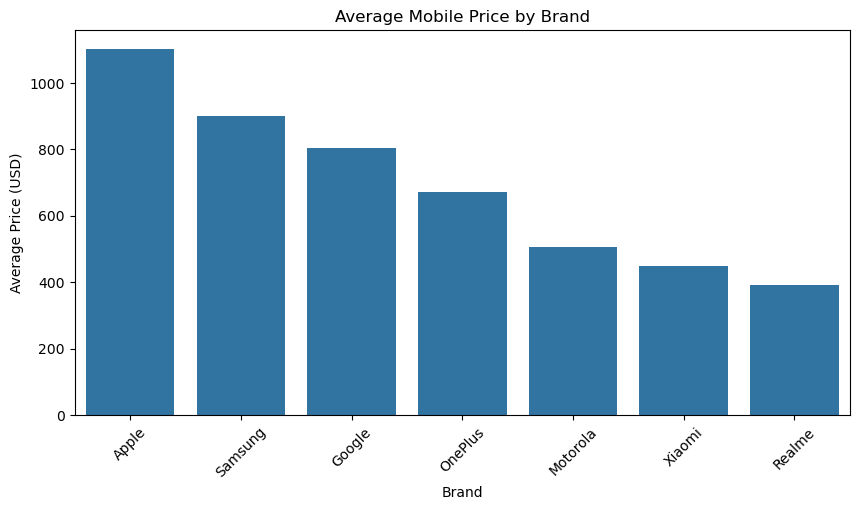

In [132]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=brand_price.index,
    y=brand_price.values
)

plt.title("Average Mobile Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)
plt.show()

In [133]:
brand_rating = (
    product_df.groupby("brand")["avg_rating"]
    .mean()
    .sort_values(ascending=False)
)

print(brand_rating)

brand
Realme      3.130486
OnePlus     3.125825
Apple       3.125698
Google      3.118170
Xiaomi      3.108838
Samsung     3.108261
Motorola    3.104575
Name: avg_rating, dtype: float64


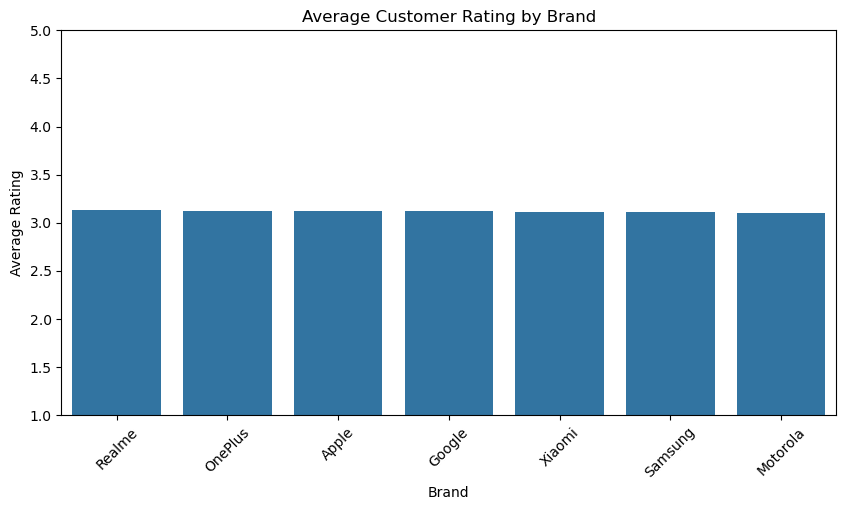

In [134]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=brand_rating.index,
    y=brand_rating.values
)

plt.title("Average Customer Rating by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Rating")
plt.ylim(1, 5)
plt.xticks(rotation=45)
plt.show()

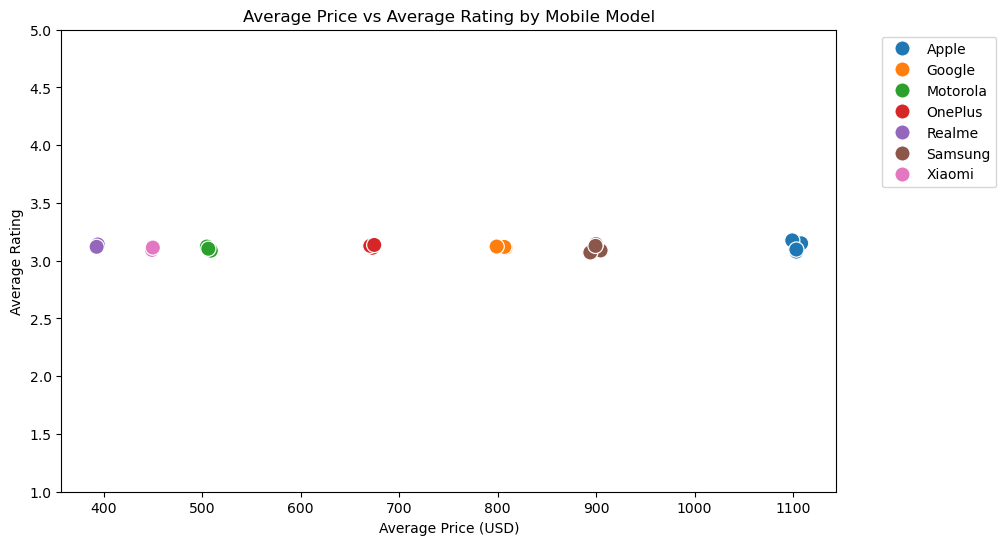

In [135]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_df,
    x="avg_price_usd",
    y="avg_rating",
    hue="brand",
    s=120
)

plt.title("Average Price vs Average Rating by Mobile Model")
plt.xlabel("Average Price (USD)")
plt.ylabel("Average Rating")
plt.ylim(1, 5)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [136]:
brand_spec = (
    product_df.groupby("brand")["avg_specification_score"]
    .mean()
    .sort_values(ascending=False)
)

print(brand_spec)

brand
Realme      2.735364
Apple       2.726481
Google      2.719819
OnePlus     2.719317
Xiaomi      2.712946
Motorola    2.708403
Samsung     2.704687
Name: avg_specification_score, dtype: float64


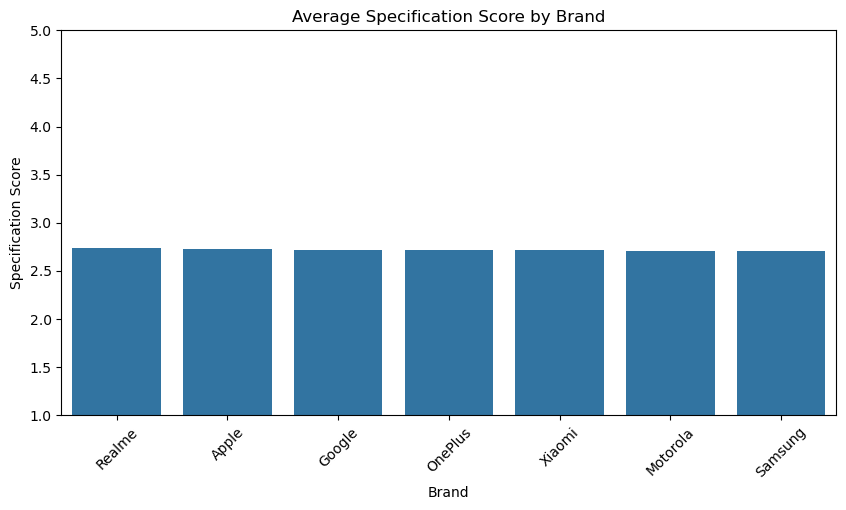

In [137]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=brand_spec.index,
    y=brand_spec.values
)

plt.title("Average Specification Score by Brand")
plt.xlabel("Brand")
plt.ylabel("Specification Score")
plt.ylim(1, 5)
plt.xticks(rotation=45)
plt.show()

In [138]:
specification_columns = [
    "avg_battery_rating",
    "avg_camera_rating",
    "avg_performance_rating",
    "avg_design_rating",
    "avg_display_rating"
]

specification_means = product_df[specification_columns].mean()

print(specification_means)

avg_battery_rating        2.717640
avg_camera_rating         2.717664
avg_performance_rating    2.717561
avg_design_rating         2.713603
avg_display_rating        2.719181
dtype: float64


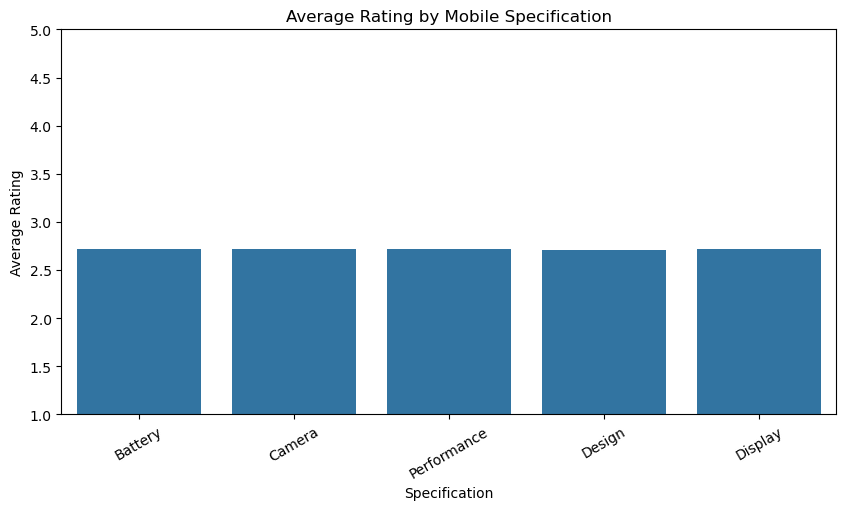

In [139]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=specification_means.index,
    y=specification_means.values
)

plt.title("Average Rating by Mobile Specification")
plt.xlabel("Specification")
plt.ylabel("Average Rating")
plt.ylim(1, 5)

plt.xticks(
    range(len(specification_means)),
    ["Battery", "Camera", "Performance", "Design", "Display"],
    rotation=30
)

plt.show()

In [140]:
ml_features = [
    "avg_price_usd",
    "avg_rating",
    "avg_battery_rating",
    "avg_camera_rating",
    "avg_performance_rating",
    "avg_design_rating",
    "avg_display_rating",
    "avg_specification_score",
    "avg_helpful_votes",
    "verified_purchase_rate"
]

X = product_df[ml_features].copy()

print("Feature dataset shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

Feature dataset shape: (22, 10)

Features:
['avg_price_usd', 'avg_rating', 'avg_battery_rating', 'avg_camera_rating', 'avg_performance_rating', 'avg_design_rating', 'avg_display_rating', 'avg_specification_score', 'avg_helpful_votes', 'verified_purchase_rate']


In [141]:
X.head()

,avg_price_usd,avg_rating,avg_battery_rating,avg_camera_rating,avg_performance_rating,avg_design_rating,avg_display_rating,avg_specification_score,avg_helpful_votes,verified_purchase_rate
0,1108.265433,3.150538,2.754952,2.754952,2.765139,2.765139,2.710243,2.750085,3.743067,0.795133
1,1099.219883,3.176174,2.738255,2.781879,2.723714,2.773490,2.758949,2.755257,3.690716,0.815436
2,1103.409883,3.079197,2.677635,2.707195,2.661461,2.675404,2.691021,2.682543,3.570552,0.785276
3,1103.381041,3.096882,2.727728,2.703786,2.732183,2.690980,2.735523,2.718040,3.575724,0.796214
4,807.921013,3.112232,2.712064,2.709962,2.689786,2.706179,2.715427,2.706683,3.691047,0.800336


In [142]:
X.describe()

,avg_price_usd,avg_rating,avg_battery_rating,avg_camera_rating,avg_performance_rating,avg_design_rating,avg_display_rating,avg_specification_score,avg_helpful_votes,verified_purchase_rate
count,22.0,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,731.766799,3.116774,2.717640,2.717664,2.717561,2.713603,2.719181,2.717130,3.643401,0.801236
std,249.960355,0.024880,0.020702,0.026468,0.034999,0.030079,0.026303,0.022789,0.048875,0.009181
min,392.706775,3.071550,2.674730,2.663827,2.650199,2.669530,2.651007,2.667802,3.549441,0.783039
25%,504.992791,3.098653,2.711657,2.704360,2.694567,2.691514,2.709631,2.707304,3.614736,0.797208
50%,736.817045,3.119309,2.721265,2.714914,2.722382,2.711898,2.718039,2.721023,3.643278,0.799751
75%,899.655534,3.128623,2.730843,2.731493,2.742833,2.731777,2.737190,2.731400,3.675609,0.803607
max,1108.265433,3.176174,2.754952,2.781879,2.765139,2.773490,2.758949,2.755257,3.743067,0.820695


In [143]:
ml_features = [
    "avg_price_usd",
    "avg_rating",
    "avg_battery_rating",
    "avg_camera_rating",
    "avg_performance_rating",
    "avg_design_rating",
    "avg_display_rating",
    "avg_helpful_votes",
    "verified_purchase_rate"
]

X = product_df[ml_features].copy()

print("Final ML feature shape:", X.shape)
print(X.columns.tolist())

Final ML feature shape: (22, 9)
['avg_price_usd', 'avg_rating', 'avg_battery_rating', 'avg_camera_rating', 'avg_performance_rating', 'avg_design_rating', 'avg_display_rating', 'avg_helpful_votes', 'verified_purchase_rate']


In [144]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (22, 9)


In [145]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=ml_features
)

X_scaled_df.describe()

,avg_price_usd,avg_rating,avg_battery_rating,avg_camera_rating,avg_performance_rating,avg_design_rating,avg_display_rating,avg_helpful_votes,verified_purchase_rate
count,2.200000e+01,2.200000e+01,2.200000e+01,2.200000e+01,2.200000e+01,2.200000e+01,2.200000e+01,2.200000e+01,2.200000e+01
mean,-3.633457e-16,1.414588e-14,6.993143e-15,2.343580e-14,5.775052e-16,-1.651835e-14,-1.100130e-14,-4.213801e-16,5.076747e-15
std,1.023533e+00,1.023533e+00,1.023533e+00,1.023533e+00,1.023533e+00,1.023533e+00,1.023533e+00,1.023533e+00,1.023533e+00
min,-1.388376e+00,-1.860436e+00,-2.121516e+00,-2.081881e+00,-1.969956e+00,-1.499722e+00,-2.652881e+00,-1.967707e+00,-2.028788e+00
25%,-9.285896e-01,-7.454707e-01,-2.957885e-01,-5.144526e-01,-6.724313e-01,-7.516400e-01,-3.716143e-01,-6.003082e-01,-4.491599e-01
50%,2.067964e-02,1.042879e-01,1.791987e-01,-1.063300e-01,1.409987e-01,-5.800431e-02,-4.443260e-02,-2.577210e-03,-1.656448e-01
75%,6.874674e-01,4.874523e-01,6.527578e-01,5.347954e-01,7.390640e-01,6.184282e-01,7.007903e-01,6.744933e-01,2.642677e-01
max,1.541679e+00,2.443625e+00,1.844734e+00,2.483244e+00,1.391390e+00,2.037855e+00,1.547464e+00,2.087193e+00,2.169477e+00


In [146]:
#Calculate inertia

In [147]:
from sklearn.cluster import KMeans

inertia = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print("K values:", list(k_values))
print("Inertia values:", inertia)

C:\Users\12622\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\12622\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\12622\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\12622\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

K values: [2, 3, 4, 5, 6, 7, 8]
Inertia values: [132.88568483517614, 100.6010793055714, 89.10041260135631, 73.93476560292167, 65.27821362529997, 57.87206964774251, 50.21118032762446]


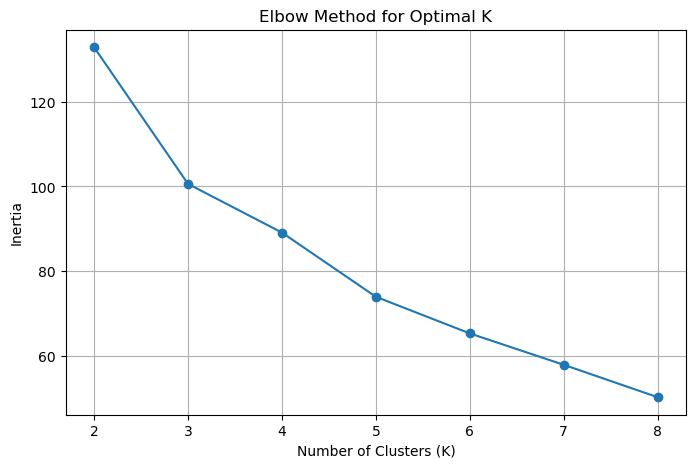

In [148]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [149]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

print("K values:", list(k_values))
print("Silhouette scores:", silhouette_scores)

K values: [2, 3, 4, 5, 6, 7, 8]
Silhouette scores: [0.2926878987990676, 0.24389984802762574, 0.16962339540351035, 0.1622679840947101, 0.14919524322995273, 0.1549867413595022, 0.18086580867031524]


C:\Users\12622\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\12622\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\12622\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\12622\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

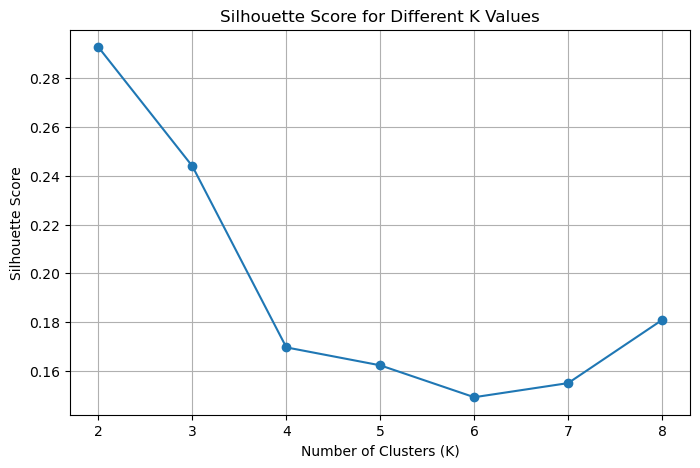

In [150]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [151]:
optimal_k = 2

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

product_df["cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")

K-Means clustering completed!


C:\Users\12622\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [152]:
print(product_df["cluster"].value_counts().sort_index())

cluster
0     5
1    17
Name: count, dtype: int64


In [153]:
cluster_products = product_df[
    ["brand", "model", "cluster"]
].sort_values(["cluster", "brand"])

cluster_products


,brand,model,cluster
2,Apple,iPhone 15 Pro,0
7,Motorola,Edge 50,0
15,Samsung,Galaxy A55,0
17,Samsung,Galaxy S24,0
19,Xiaomi,Mi 13 Pro,0
0,Apple,iPhone 13,1
1,Apple,iPhone 14,1
3,Apple,iPhone SE,1
4,Google,Pixel 6,1
5,Google,Pixel 7a,1


In [154]:
cluster_profile = product_df.groupby("cluster")[ml_features].mean()

cluster_profile

,avg_price_usd,avg_rating,avg_battery_rating,avg_camera_rating,avg_performance_rating,avg_design_rating,avg_display_rating,avg_helpful_votes,verified_purchase_rate
cluster,,,,,,,,,
0,771.93715,3.084118,2.690823,2.689455,2.668981,2.680776,2.686213,3.623728,0.797207
1,719.951989,3.126379,2.725527,2.725960,2.731849,2.723258,2.728878,3.649188,0.802422


In [155]:
product_df["cluster"].value_counts().sort_index()

cluster
0     5
1    17
Name: count, dtype: int64

In [156]:
cluster_profile.round(3)

,avg_price_usd,avg_rating,avg_battery_rating,avg_camera_rating,avg_performance_rating,avg_design_rating,avg_display_rating,avg_helpful_votes,verified_purchase_rate
cluster,,,,,,,,,
0,771.937,3.084,2.691,2.689,2.669,2.681,2.686,3.624,0.797
1,719.952,3.126,2.726,2.726,2.732,2.723,2.729,3.649,0.802


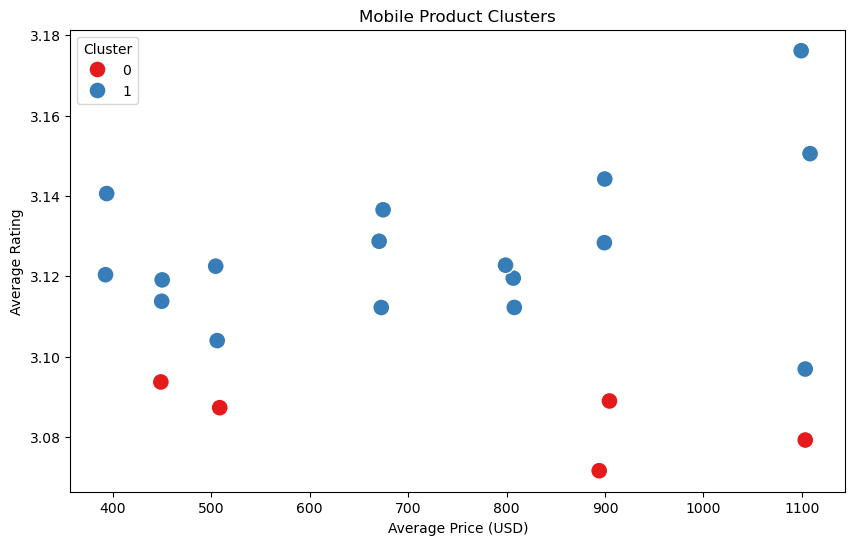

In [157]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_df,
    x="avg_price_usd",
    y="avg_rating",
    hue="cluster",
    palette="Set1",
    s=150
)

plt.title("Mobile Product Clusters")
plt.xlabel("Average Price (USD)")
plt.ylabel("Average Rating")
plt.legend(title="Cluster")
plt.show()

In [158]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

PCA shape: (22, 2)
Explained variance ratio: [0.5095327  0.14315294]
Total explained variance: 0.6526856425421195


In [159]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = product_df["cluster"].values
pca_df["model"] = product_df["model"].values
pca_df["brand"] = product_df["brand"].values

pca_df.head()

,PC1,PC2,cluster,model,brand
0,3.451741,2.424023,1,iPhone 13,Apple
1,4.385488,0.743216,1,iPhone 14,Apple
2,-3.712414,1.695730,0,iPhone 15 Pro,Apple
3,-0.686706,0.606608,1,iPhone SE,Apple
4,-0.521497,0.707021,1,Pixel 6,Google


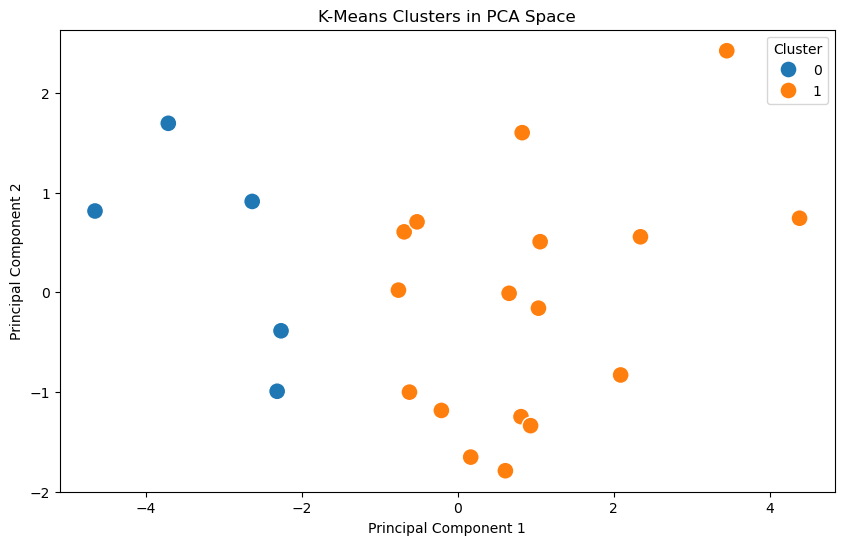

In [160]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    s=150
)

plt.title("K-Means Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [161]:
cluster_0 = product_df[
    product_df["cluster"] == 0
][["brand", "model", "avg_price_usd", "avg_rating",
   "avg_specification_score", "review_count"]]

cluster_0.sort_values("avg_price_usd", ascending=False)

,brand,model,avg_price_usd,avg_rating,avg_specification_score,review_count
2,Apple,iPhone 15 Pro,1103.409883,3.079197,2.682543,1793
15,Samsung,Galaxy A55,904.538428,3.088926,2.680872,1788
17,Samsung,Galaxy S24,894.125713,3.071550,2.667802,1761
7,Motorola,Edge 50,508.697622,3.087257,2.695378,2315
19,Xiaomi,Mi 13 Pro,448.914106,3.093661,2.689652,2445


In [162]:
cluster_1 = product_df[
    product_df["cluster"] == 1
][["brand", "model", "avg_price_usd", "avg_rating",
   "avg_specification_score", "review_count"]]

cluster_1.sort_values("avg_price_usd", ascending=False)

,brand,model,avg_price_usd,avg_rating,avg_specification_score,review_count
0,Apple,iPhone 13,1108.265433,3.150538,2.750085,1767
3,Apple,iPhone SE,1103.381041,3.096882,2.718040,1796
1,Apple,iPhone 14,1099.219883,3.176174,2.755257,1788
16,Samsung,Galaxy Note 20,899.746233,3.144215,2.739966,1789
18,Samsung,Galaxy Z Flip,899.383436,3.128355,2.730105,1714
4,Google,Pixel 6,807.921013,3.112232,2.706683,2379
5,Google,Pixel 7a,806.821422,3.119530,2.728768,2468
6,Google,Pixel 8,798.969673,3.122748,2.724005,2387
12,OnePlus,OnePlus Nord 3,674.664416,3.136555,2.724118,2380
10,OnePlus,OnePlus 11R,672.786584,3.112207,2.709166,2433


In [163]:
cluster_comparison = product_df.groupby("cluster").agg(
    products=("model", "count"),
    avg_price=("avg_price_usd", "mean"),
    avg_rating=("avg_rating", "mean"),
    avg_battery=("avg_battery_rating", "mean"),
    avg_camera=("avg_camera_rating", "mean"),
    avg_performance=("avg_performance_rating", "mean"),
    avg_design=("avg_design_rating", "mean"),
    avg_display=("avg_display_rating", "mean"),
    avg_helpful_votes=("avg_helpful_votes", "mean"),
    avg_verified_rate=("verified_purchase_rate", "mean")
)

cluster_comparison.round(3)

,products,avg_price,avg_rating,avg_battery,avg_camera,avg_performance,avg_design,avg_display,avg_helpful_votes,avg_verified_rate
cluster,,,,,,,,,,
0,5,771.937,3.084,2.691,2.689,2.669,2.681,2.686,3.624,0.797
1,17,719.952,3.126,2.726,2.726,2.732,2.723,2.729,3.649,0.802


In [164]:
pd.crosstab(
    product_df["cluster"],
    product_df["brand"]
)

brand,Apple,Google,Motorola,OnePlus,Realme,Samsung,Xiaomi
cluster,,,,,,,
0,1,0,1,0,0,2,1
1,3,3,2,3,2,2,2


In [165]:
final_silhouette = silhouette_score(
    X_scaled,
    product_df["cluster"]
)

print("Final Silhouette Score:", round(final_silhouette, 4))

Final Silhouette Score: 0.2927


In [166]:
final_cluster_summary = product_df.groupby("cluster").agg(
    product_count=("model", "count"),
    avg_price_usd=("avg_price_usd", "mean"),
    avg_rating=("avg_rating", "mean"),
    avg_specification_score=("avg_specification_score", "mean"),
    avg_helpful_votes=("avg_helpful_votes", "mean"),
    verified_purchase_rate=("verified_purchase_rate", "mean")
).round(3)

final_cluster_summary

,product_count,avg_price_usd,avg_rating,avg_specification_score,avg_helpful_votes,verified_purchase_rate
cluster,,,,,,
0,5,771.937,3.084,2.683,3.624,0.797
1,17,719.952,3.126,2.727,3.649,0.802


In [167]:
final_silhouette = silhouette_score(
    X_scaled,
    product_df["cluster"]
)

print("Final Silhouette Score:", round(final_silhouette, 4))

Final Silhouette Score: 0.2927


In [168]:
recommendation_features = [
    "avg_price_usd",
    "avg_rating",
    "avg_battery_rating",
    "avg_camera_rating",
    "avg_performance_rating",
    "avg_design_rating",
    "avg_display_rating"
]

recommendation_matrix = product_df[recommendation_features].copy()

recommendation_matrix.head()

,avg_price_usd,avg_rating,avg_battery_rating,avg_camera_rating,avg_performance_rating,avg_design_rating,avg_display_rating
0,1108.265433,3.150538,2.754952,2.754952,2.765139,2.765139,2.710243
1,1099.219883,3.176174,2.738255,2.781879,2.723714,2.773490,2.758949
2,1103.409883,3.079197,2.677635,2.707195,2.661461,2.675404,2.691021
3,1103.381041,3.096882,2.727728,2.703786,2.732183,2.690980,2.735523
4,807.921013,3.112232,2.712064,2.709962,2.689786,2.706179,2.715427


In [169]:
recommendation_scaler = StandardScaler()

recommendation_scaled = recommendation_scaler.fit_transform(
    recommendation_matrix
)

print("Recommendation matrix shape:", recommendation_scaled.shape)

Recommendation matrix shape: (22, 7)


In [170]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(recommendation_scaled)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (22, 22)


In [171]:
def recommend_mobile(model_name, top_n=5):
    
    if model_name not in product_df["model"].values:
        return f"Model '{model_name}' not found."
    
    model_index = product_df.index[
        product_df["model"] == model_name
    ][0]
    
    similarity_scores = similarity_matrix[model_index]
    
    similar_indices = similarity_scores.argsort()[::-1]
    
    recommendations = []
    
    for index in similar_indices:
        if index == model_index:
            continue
        
        recommendations.append({
            "model": product_df.loc[index, "model"],
            "brand": product_df.loc[index, "brand"],
            "similarity_score": similarity_scores[index]
        })
        
        if len(recommendations) == top_n:
            break
    
    return pd.DataFrame(recommendations)

In [172]:
recommend_mobile("OnePlus 12", top_n=5)

,model,brand,similarity_score
0,iPhone 13,Apple,0.625824
1,iPhone 14,Apple,0.589862
2,Galaxy Note 20,Samsung,0.489501
3,Realme Narzo 70,Realme,0.445864
4,Redmi Note 13,Xiaomi,0.421150


In [173]:
test_models = [
    "iPhone 15 Pro",
    "Pixel 8",
    "Galaxy S24",
    "Redmi Note 13",
    "Realme Narzo 70"
]

for model in test_models:
    print(f"\n{'='*50}")
    print(f"Recommendations for: {model}")
    print(f"{'='*50}")
    print(recommend_mobile(model, top_n=5))


Recommendations for: iPhone 15 Pro
         model     brand  similarity_score
0   Galaxy S24   Samsung          0.892859
1      Pixel 6    Google          0.840245
2   Galaxy A55   Samsung          0.661793
3      Edge 50  Motorola          0.657126
4  OnePlus 11R   OnePlus          0.620819

Recommendations for: Pixel 8
            model    brand  similarity_score
0       iPhone 14    Apple          0.584877
1  Galaxy Note 20  Samsung          0.416166
2        Pixel 7a   Google          0.402385
3       iPhone 13    Apple          0.373908
4   Realme 12 Pro   Realme          0.194222

Recommendations for: Galaxy S24
           model     brand  similarity_score
0  iPhone 15 Pro     Apple          0.892859
1     Galaxy A55   Samsung          0.834486
2        Pixel 6    Google          0.833662
3    OnePlus 11R   OnePlus          0.752660
4        Edge 50  Motorola          0.740562

Recommendations for: Redmi Note 13
             model     brand  similarity_score
0     Moto G Power  

In [174]:
for model in test_models:
    recommendations = recommend_mobile(model, top_n=5)
    
    print(f"\n{model}")
    print(recommendations[["model", "brand", "similarity_score"]])


iPhone 15 Pro
         model     brand  similarity_score
0   Galaxy S24   Samsung          0.892859
1      Pixel 6    Google          0.840245
2   Galaxy A55   Samsung          0.661793
3      Edge 50  Motorola          0.657126
4  OnePlus 11R   OnePlus          0.620819

Pixel 8
            model    brand  similarity_score
0       iPhone 14    Apple          0.584877
1  Galaxy Note 20  Samsung          0.416166
2        Pixel 7a   Google          0.402385
3       iPhone 13    Apple          0.373908
4   Realme 12 Pro   Realme          0.194222

Galaxy S24
           model     brand  similarity_score
0  iPhone 15 Pro     Apple          0.892859
1     Galaxy A55   Samsung          0.834486
2        Pixel 6    Google          0.833662
3    OnePlus 11R   OnePlus          0.752660
4        Edge 50  Motorola          0.740562

Redmi Note 13
             model     brand  similarity_score
0     Moto G Power  Motorola          0.574350
1  Realme Narzo 70    Realme          0.467849
2       On

In [175]:
def recommend_mobile(model_name, top_n=5):
    
    if model_name not in product_df["model"].values:
        return f"Model '{model_name}' not found."
    
    model_index = product_df.index[
        product_df["model"] == model_name
    ][0]
    
    similarity_scores = similarity_matrix[model_index]
    
    similar_indices = similarity_scores.argsort()[::-1]
    
    recommendations = []
    
    for index in similar_indices:
        if index == model_index:
            continue
        
        recommendations.append({
            "model": product_df.loc[index, "model"],
            "brand": product_df.loc[index, "brand"],
            "avg_price_usd": round(
                product_df.loc[index, "avg_price_usd"], 2
            ),
            "avg_rating": round(
                product_df.loc[index, "avg_rating"], 2
            ),
            "specification_score": round(
                product_df.loc[index, "avg_specification_score"], 2
            ),
            "similarity_score": round(
                similarity_scores[index], 3
            ),
            "cluster": product_df.loc[index, "cluster"]
        })
        
        if len(recommendations) == top_n:
            break
    
    return pd.DataFrame(recommendations)

In [176]:
recommend_mobile("iPhone 15 Pro", top_n=5)


,model,brand,avg_price_usd,avg_rating,specification_score,similarity_score,cluster
0,Galaxy S24,Samsung,894.13,3.07,2.67,0.893,0
1,Pixel 6,Google,807.92,3.11,2.71,0.840,1
2,Galaxy A55,Samsung,904.54,3.09,2.68,0.662,0
3,Edge 50,Motorola,508.70,3.09,2.70,0.657,0
4,OnePlus 11R,OnePlus,672.79,3.11,2.71,0.621,1


In [177]:
recommend_mobile("iPhone 999", top_n=5)

"Model 'iPhone 999' not found."

In [178]:
output_file = "mobile_product_segmentation.csv"

product_df.to_csv(
    output_file,
    index=False
)

print(f"Saved successfully: {output_file}")

Saved successfully: mobile_product_segmentation.csv


In [179]:
print(product_df.shape)
print(product_df.columns.tolist())

(22, 14)
['brand', 'model', 'avg_price_usd', 'avg_rating', 'avg_battery_rating', 'avg_camera_rating', 'avg_performance_rating', 'avg_design_rating', 'avg_display_rating', 'avg_specification_score', 'avg_helpful_votes', 'review_count', 'verified_purchase_rate', 'cluster']


In [180]:
product_df.to_csv(
    "mobile_product_segmentation.csv",
    index=False
)

print("Final product dataset saved successfully!")

Final product dataset saved successfully!


In [181]:
import os

print(os.path.abspath("mobile_product_segmentation.csv"))

C:\Users\12622\Desktop\guvi_projects\Mobile_Product_Segmentation_Recommendation\mobile_product_segmentation.csv


In [182]:
np.save(
    "similarity_matrix.npy",
    similarity_matrix
)

print("Similarity matrix saved successfully!")

Similarity matrix saved successfully!


In [183]:
print("Recommendation features:")
print(recommendation_features)

Recommendation features:
['avg_price_usd', 'avg_rating', 'avg_battery_rating', 'avg_camera_rating', 'avg_performance_rating', 'avg_design_rating', 'avg_display_rating']


In [184]:
np.save("similarity_matrix.npy", similarity_matrix)

print("Similarity matrix saved successfully!")

Similarity matrix saved successfully!


In [185]:
import os

print("Product dataset:")
print(os.path.abspath("mobile_product_segmentation.csv"))

print("\nSimilarity matrix:")
print(os.path.abspath("similarity_matrix.npy"))

Product dataset:
C:\Users\12622\Desktop\guvi_projects\Mobile_Product_Segmentation_Recommendation\mobile_product_segmentation.csv

Similarity matrix:
C:\Users\12622\Desktop\guvi_projects\Mobile_Product_Segmentation_Recommendation\similarity_matrix.npy


In [186]:
import os

files_to_check = [
    "mobile_product_segmentation.csv",
    "similarity_matrix.npy"
]

for file in files_to_check:
    print(file, "→", os.path.exists(file))

mobile_product_segmentation.csv → True
similarity_matrix.npy → True
